## Paso 1.- Importar Librerias

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score)

## Paso 2.- Cargar Dataset

In [2]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# Descarga el dataset desde: /data/processed/coffee_quality_clean.csv
# La ruta no modificarla. Y poner el mismo nombre todos.

df = pd.read_csv('../data/processed/ObesityDataSet_clean_jm.csv')

print(f'✅ Dataset cargado correctamente')
print(f'📊 Dimensiones df: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset cargado correctamente
📊 Dimensiones df: 2111 filas x 17 columnas


## Paso 3.- Preprocesamiento de Datos

Qué hacer con las siguientes columnas : SMOKE, MTRANS, SCC y Gender.

Mantengo Gender y borro las demás.

In [3]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres
df = df.drop(['SMOKE', 'MTRANS', 'SCC'], axis=1)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   CH2O                            2111 non-null   float64
 10  FAF                             2111 non-null   float64
 11  TUE                             2111 non-null   float64
 12  CALC                            2111 non-null

### Que hacer con las columnas Gender, family_history_with_overweight, FAVC, CAEC y CALC

##### Mapear Gender

In [5]:
# Mapear valores: Female=1, Male=0
# Definir el mapeo de múltiples valores
mapeo = {'Female': 0, 'Male': 1}

df['Gender'] = df['Gender'].map(mapeo)


##### Mapear family_history_with_overweight

In [6]:
# Mapear valores: yes=1, no=0
# Definir el mapeo de múltiples valores
mapeo = {'yes': 0, 'no': 1}

df['family_history_with_overweight'] = df['family_history_with_overweight'].map(mapeo)

##### Mapear FAVC

In [7]:
# Mapear valores: yes=1, no=0
# Definir el mapeo de múltiples valores
mapeo = {'yes': 0, 'no': 1}

df['FAVC'] = df['FAVC'].map(mapeo)

##### Mapear CAEC

In [8]:
# Mapear valores: Sometimes=0.5, Frequently=0.75, Always=1, no=0
# Definir el mapeo de múltiples valores
mapeo = {'Sometimes': 0.5, 'Frequently': 0.75, 'Always': 1, 'no': 0}

df['CAEC'] = df['CAEC'].map(mapeo)

##### Mapear CALC

In [9]:
# Mapear valores: Sometimes=0.5, Frequently=0.75, Always=1, no=0
# Definir el mapeo de múltiples valores
mapeo = {'Sometimes': 0.5, 'Frequently': 0.75, 'Always': 1, 'no': 0}

df['CALC'] = df['CALC'].map(mapeo)

In [10]:
# Comprobar las columnas cambiadas
df[['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'CALC']]

,Gender,family_history_with_overweight,FAVC,CAEC,CALC
0,0,0,1,0.5,0.00
1,0,0,1,0.5,0.50
2,1,0,1,0.5,0.75
3,1,1,1,0.5,0.75
4,1,1,1,0.5,0.50
...,...,...,...,...,...
2106,0,0,0,0.5,0.50
2107,0,0,0,0.5,0.50
2108,0,0,0,0.5,0.50
2109,0,0,0,0.5,0.50


##### Mapear columna target NObeyesdad

# Ojo preparar target_names

### -------------------------------------------------------------------------------------

In [11]:
df['NObeyesdad'].unique()

<StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str

In [12]:
# Guardar los target_names para luego mostrarlos en la matriz de confusión.
target_names = df['NObeyesdad'].unique()

### -------------------------------------------------------------------------------------

In [13]:
# Mapear valores: Normal_Weight=0, Overweight_Level_I=1, Overweight_Level_II=2, Obesity_Type_I=3, Insufficient_Weight=4, 
#                 Obesity_Type_II=5, Obesity_Type_III=6
# Definir el mapeo de múltiples valores
mapeo = {'Normal_Weight': 0, 'Overweight_Level_I': 1, 'Overweight_Level_II': 2, 'Obesity_Type_I': 3, 'Insufficient_Weight': 4,
         'Obesity_Type_II': 5, 'Obesity_Type_III': 6}

df['NObeyesdad'] = df['NObeyesdad'].map(mapeo)

In [51]:
df['NObeyesdad'].sample(10)

1746    5
1906    6
1425    3
309     0
928     1
1644    5
2101    6
1193    2
841     1
1489    3
Name: NObeyesdad, dtype: int64

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   int64  
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   int64  
 5   FAVC                            2111 non-null   int64  
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   float64
 9   CH2O                            2111 non-null   float64
 10  FAF                             2111 non-null   float64
 11  TUE                             2111 non-null   float64
 12  CALC                            2111 non-null

##### Revisar la matriz de correlación con todos los datos numéricos

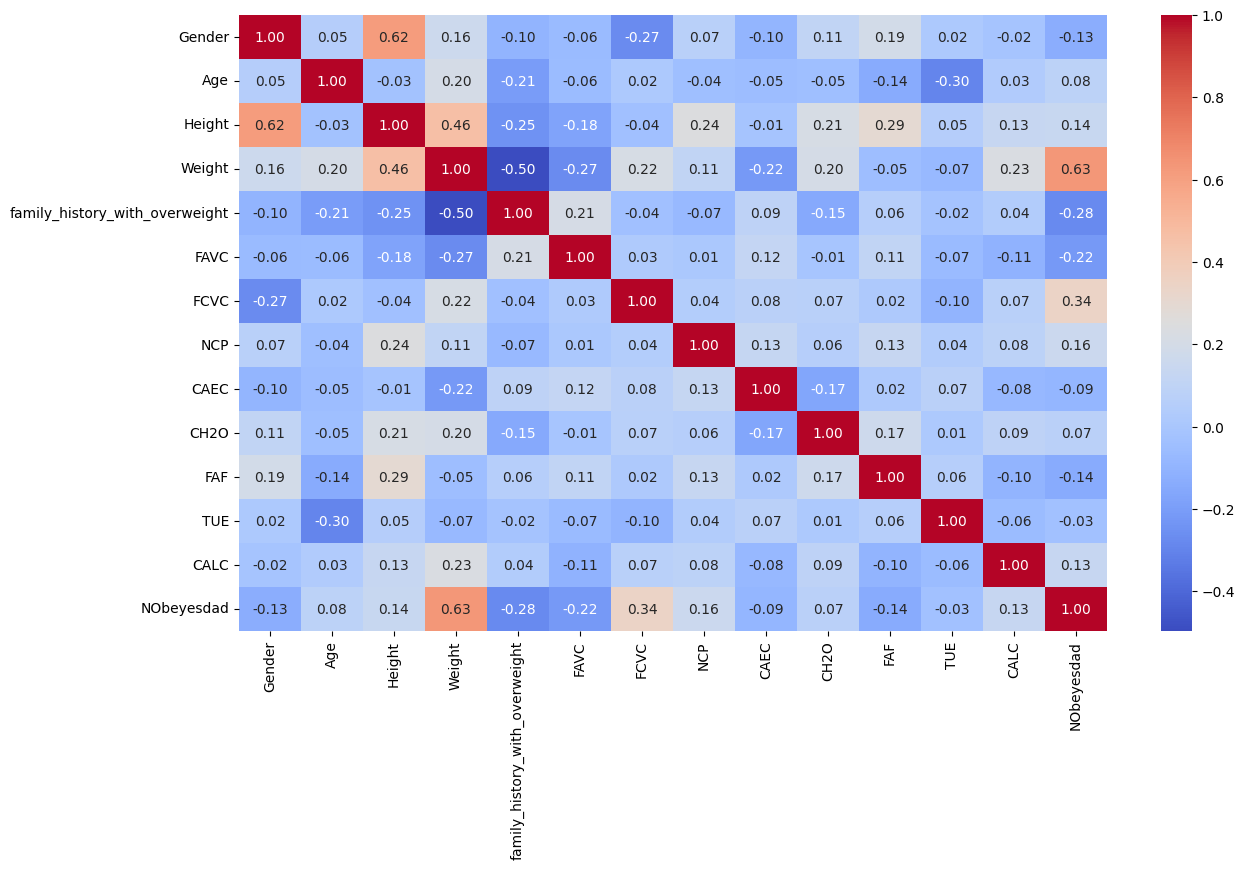

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

matriz_corr = df.corr()

# Pintar la matriz con Seaborn
plt.figure(figsize=(14, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Paso 4.- Fase de entrenamiento

### Dividir Datos en Entrenamiento y Test

In [16]:
# 1. Seleccionar características (X) y variable objetivo (y)
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

# 2. Dividir el conjunto de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Paso 5.- Evaluar el modelo

### Función para evaluar cualquier modelo

#### Preparar las librerías

In [17]:
# Para cross_val_score y StratifiedKFold
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Para precision_score, recall_score y f1_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [18]:
# ─── Función para evaluar cualquier modelo ────────────────────────────────────
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    """
    Entrena el modelo, predice en test y devuelve un diccionario con todas las métricas.
    También hace validación cruzada para ver si el modelo es estable.
    """
    # Entrenar
    modelo.fit(X_tr, y_tr)
    
    # Predecir en train
    y_pred_train = modelo.predict(X_tr)

    # Predecir en test
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)
    
    # Validación cruzada con F1 (más fiable con dataset pequeño y desbalanceado)
    cv_scores = cross_val_score(
        modelo, X_tr, y_tr,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        scoring='f1_weighted'
    )

    # Nuevo
    f1_train = f1_score(y_tr, y_pred_train, average='weighted')
    f1_test  = f1_score(y_te, y_pred, average='weighted')
    gap = f1_train - f1_test
    
    return {
        'Modelo'     : nombre,
        'Accuracy'   : accuracy_score(y_te, y_pred),
        'Precision'  : precision_score(y_te, y_pred, average='weighted'),
        'Recall'     : recall_score(y_te, y_pred, average='weighted'),
        'F1'         : f1_score(y_te, y_pred, average='weighted'),
        'ROC-AUC'    : roc_auc_score(y_te, y_prob, multi_class='ovr', average='weighted'),
        'CV F1 Media': cv_scores.mean(),
        'CV F1 Std'  : cv_scores.std(),
        'Overfitting': gap,
        'modelo_obj' : modelo
    }

print('✅ Función de evaluación lista')

✅ Función de evaluación lista


#### Evaluar modelos

##### Evaluar modelo RandomForest

#### Compruebo cuales son los mejores hiperparámetros para el modelo RndomForestClassifier

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:

# Definir el modelo
rf = RandomForestClassifier()

# Definir la rejilla de parámetros a probar
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

# Configurar GridSearchCV con validación cruzada
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1)

# Entrenar el modelo
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros
print(grid_search.best_params_)

{'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}


In [21]:
# Evaluar RandomForestClassifier
model_rf = RandomForestClassifier(max_depth=20, max_features='log2', min_samples_split=2, n_estimators=200, random_state=42)
res_random = evaluar_modelo('RandomForestClassifier', model_rf, X_train, X_test, y_train, y_test)

model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print('📊 RandomForestClassifier:')
# Esto imprime las variables de return
for k, v in res_random.items():
    if k not in ['Modelo', 'modelo_obj']:
        print(f'  {k}: {v:.4f}')

📊 RandomForestClassifier:
  Accuracy: 0.9433
  Precision: 0.9439
  Recall: 0.9433
  F1: 0.9434
  ROC-AUC: 0.9969
  CV F1 Media: 0.9469
  CV F1 Std: 0.0073
  Overfitting: 0.0566


#### Visualiza la matriz de confusión de RandomForestClassifier

Matriz de Confusión:
[[55  5  0  0  2  0  0]
 [ 6 49  1  0  0  0  0]
 [ 0  2 48  0  0  0  0]
 [ 0  0  3 73  0  2  0]
 [ 2  0  0  0 54  0  0]
 [ 0  0  0  1  0 57  0]
 [ 0  0  0  0  0  0 63]]


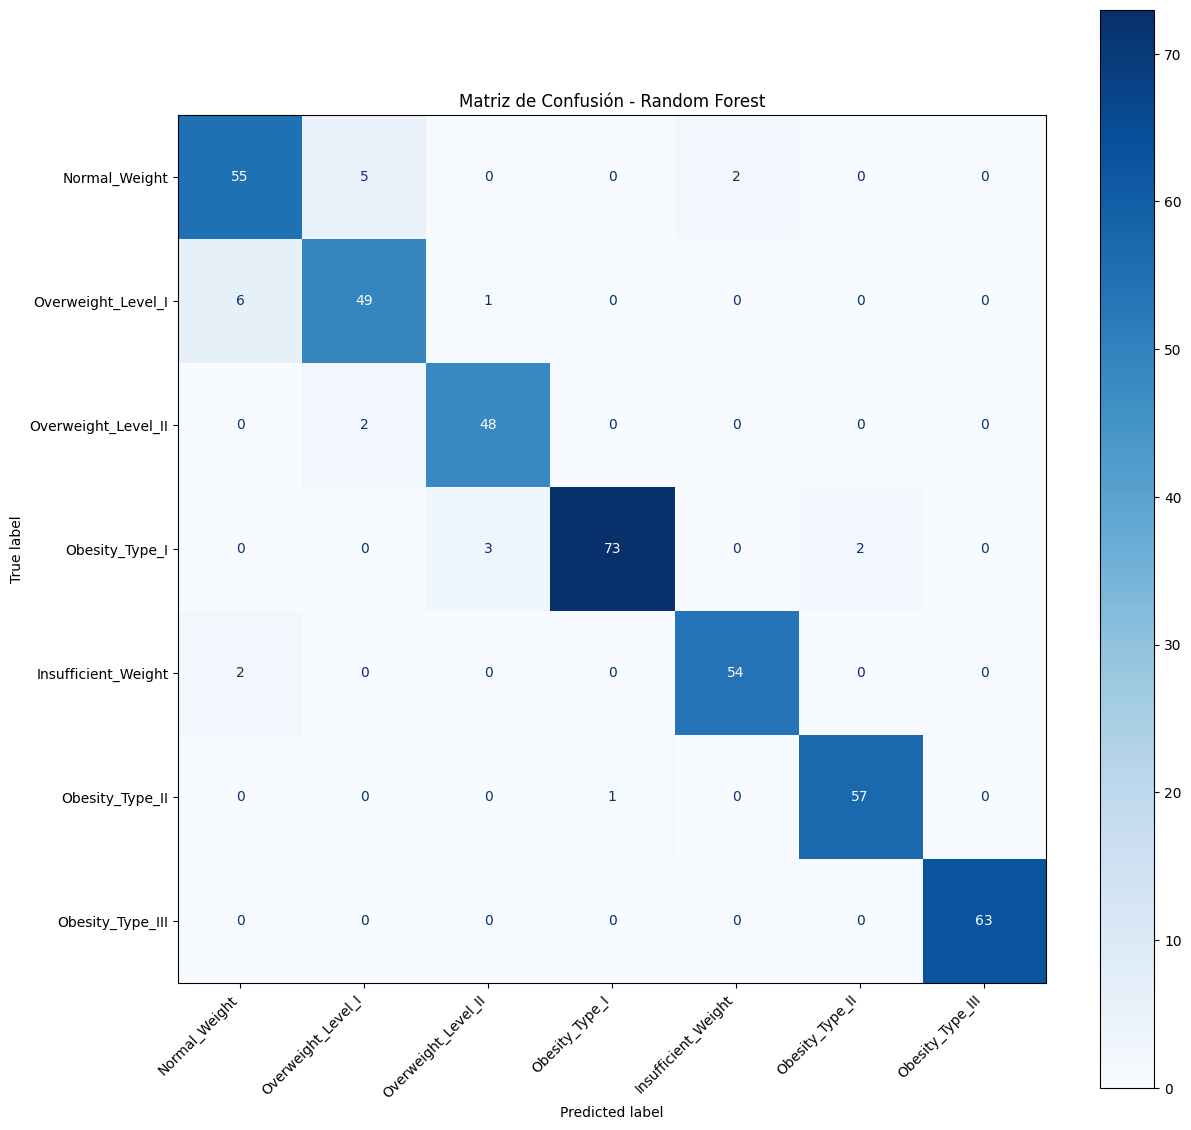

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 14))

# 1. Obtener la matriz de confusión numérica
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(matriz)

# 2. Visualizar la matriz de confusión (Opcional)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax)

# Rotar etiquetas del eje X
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.title("Matriz de Confusión - Random Forest")
plt.show()

#### Evaluar modelo XGBClassifier

##### Compruebo cuales son los mejores hiperparámetros para el modelo XGBClassifier

In [40]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

In [41]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(),
    param_grid=param_grid,
    cv=5, # Validación cruzada
    scoring='accuracy'
)

# Entrenar pasando el DataFrame de Pandas
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [44]:
# Evaluar XGBoost (Ensemble)
model = xgb.XGBClassifier(max_depth=5, n_estimators=200, learning_rate=0.1, subsample=1.0, colsample_bytree=0.8)
res_xgboost = evaluar_modelo('XGBoost', model, X_train, X_test, y_train, y_test)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('📊 XGBoost:')
# Esto imprime las variables de return
for k, v in res_xgboost.items():
    if k not in ['Modelo', 'modelo_obj']:
        print(f'  {k}: {v:.4f}')

📊 XGBoost:
  Accuracy: 0.9598
  Precision: 0.9611
  Recall: 0.9598
  F1: 0.9598
  ROC-AUC: 0.9990
  CV F1 Media: 0.9651
  CV F1 Std: 0.0086
  Overfitting: 0.0402


#### Visualiza la matriz de confusión de XGBClassifier

Matriz de Confusión:
[[54  5  0  0  3  0  0]
 [ 3 53  0  0  0  0  0]
 [ 0  2 48  0  0  0  0]
 [ 0  1  0 75  0  2  0]
 [ 0  0  0  0 56  0  0]
 [ 0  0  0  1  0 57  0]
 [ 0  0  0  0  0  0 63]]


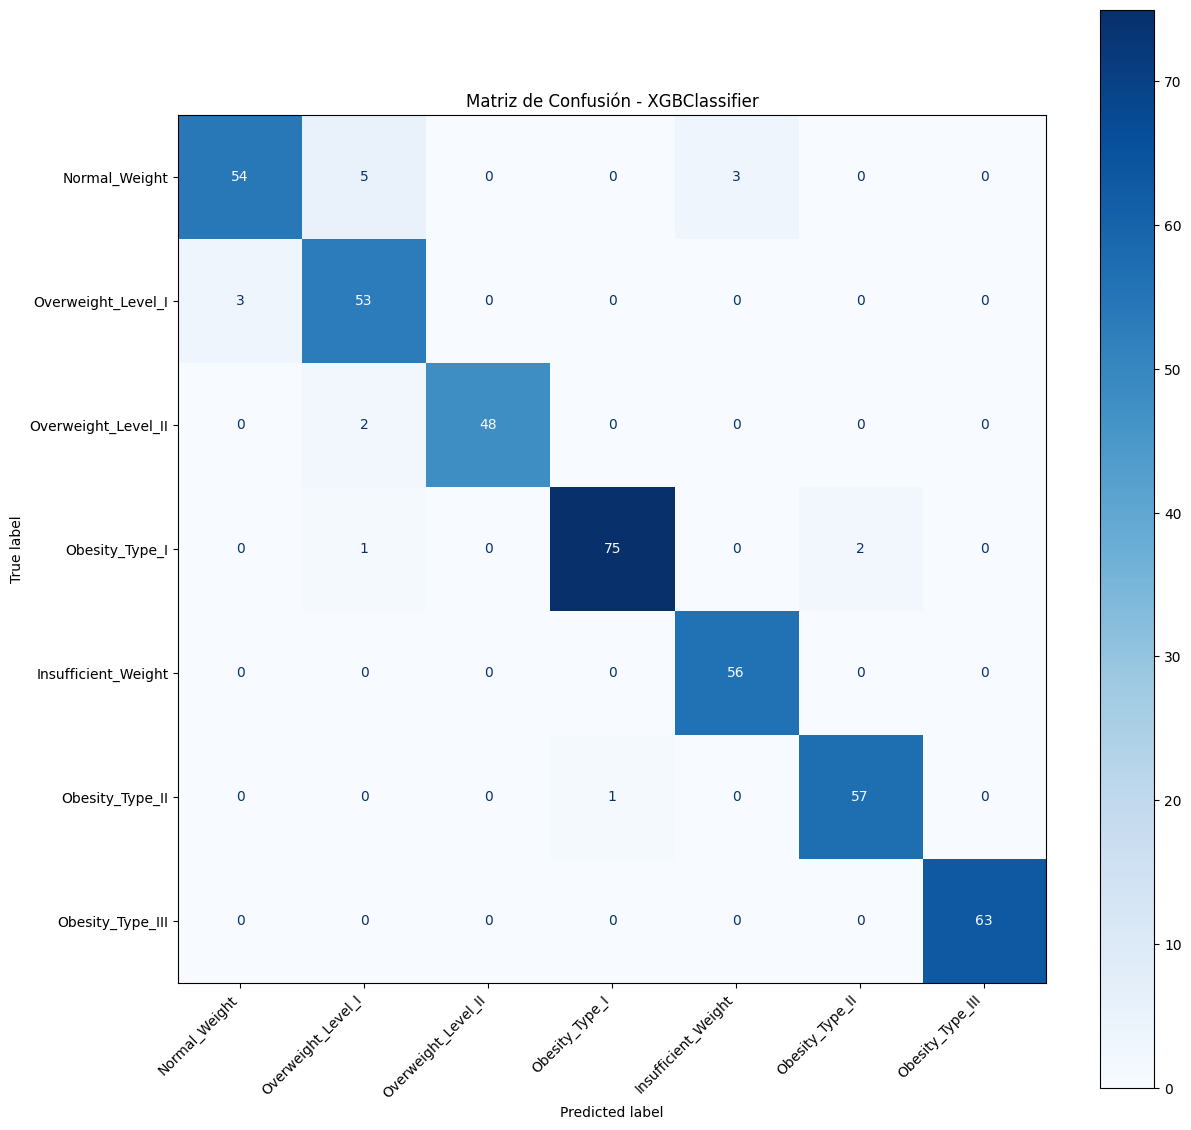

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 14))

# 1. Obtener la matriz de confusión numérica
matriz = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(matriz)

# 2. Visualizar la matriz de confusión (Opcional)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax)

# Rotar etiquetas del eje X
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.title("Matriz de Confusión - XGBClassifier")
plt.show()

#### Ver los pesos y la importancia de las características

In [47]:
import xgboost as xgb
import pandas as pd

# Obtener los pesos
importances = model.feature_importances_

# Crear un DataFrame para mejor visualización
feature_names = X_train.columns # si usas pandas
feature_imp_df = pd.DataFrame({'Característica': feature_names, 'Peso': importances})
feature_imp_df = feature_imp_df.sort_values(by='Peso', ascending=False)

print(feature_imp_df)

                    Característica      Peso
0                           Gender  0.228975
3                           Weight  0.139576
6                             FCVC  0.123173
8                             CAEC  0.074797
4   family_history_with_overweight  0.070513
7                              NCP  0.058130
11                             TUE  0.053734
5                             FAVC  0.052414
2                           Height  0.046134
12                            CALC  0.045843
1                              Age  0.039507
9                             CH2O  0.037365
10                             FAF  0.029838


<Figure size 1000x800 with 0 Axes>

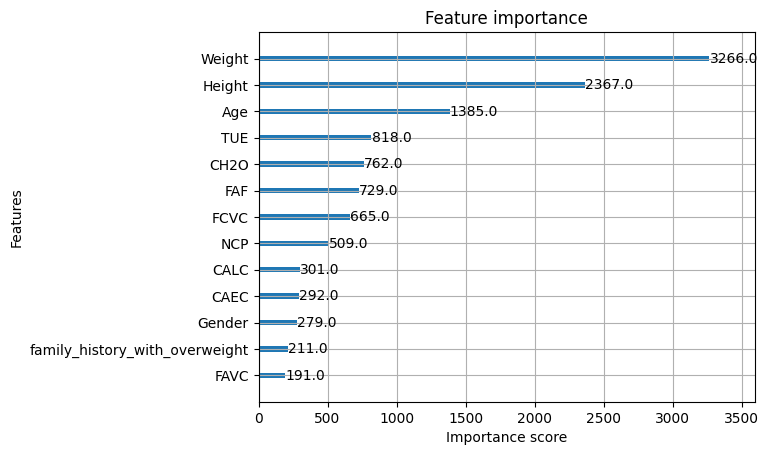

In [48]:
import matplotlib.pyplot as plt

# 3. Graficar pesos (Importancia por peso/frecuencia)
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, importance_type='weight') # 'weight' es el default
plt.show()

<Figure size 1000x800 with 0 Axes>

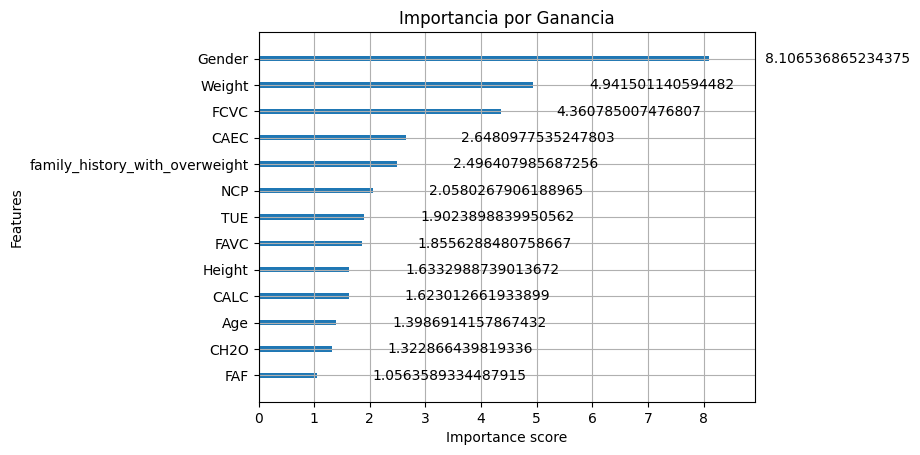

In [49]:
# Graficar por ganancia (cuánto mejora el modelo)
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, importance_type='gain', title='Importancia por Ganancia')
plt.show()

#### Guardar el modelo entrenado

In [50]:
import joblib

# --- 3. Guardar el modelo y los datos de entrenamiento---
# Se recomienda usar joblib para modelos scikit-learn
joblib.dump(model, '../models/model_jm.pkl')
print("Modelo guardado como 'model_jm.pkl'")

# Encoders de categóricas (necesario para transformar datos nuevos en la app)
#joblib.dump(encoders, f'../../models/Jonathan/encoders.pkl')

# Lista de columnas en el orden exacto del entrenamiento
# joblib.dump(list(X.columns), f'../../models/Juanma/feature_names.pkl')

# joblib.dump(X_train, '../../models/Juanma/X_train.pkl')
# joblib.dump(X_test,  '../../models/Juanma/X_test.pkl')
# joblib.dump(y_train, '../../models/Juanma/y_train.pkl')
# joblib.dump(y_test,  '../../models/Juanma/y_test.pkl')
# print("Resto modelos guardados como '.pkl'")


Modelo guardado como 'model_jm.pkl'


### Probar el modelo

In [ ]:
df.sample(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC,NObeyesdad
199,0,23.000000,1.660000,60.000000,0,0,2.000000,1.0,0.50,1.000000,1.000000,1.000000,0.5,0
1766,1,30.702559,1.861980,126.418413,0,0,2.927187,3.0,0.50,1.508796,0.902776,1.015467,0.5,5
350,1,17.000000,1.750000,70.000000,0,1,2.000000,3.0,0.50,1.000000,3.000000,2.000000,0.5,0
1476,1,21.688557,1.807029,105.696358,0,0,2.055209,3.0,0.50,2.885852,0.903369,0.144510,0.5,3
602,0,19.773303,1.602082,45.000000,1,1,3.000000,3.0,0.75,2.875583,1.258504,0.000000,0.5,4


In [54]:
X_test.head(2)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,CH2O,FAF,TUE,CALC
544,0,20.406871,1.755978,53.699561,0,0,2.0,3.891994,0.75,1.863930,2.870127,2.000000,0.0
1987,0,26.000000,1.624950,111.004920,0,0,3.0,3.000000,0.50,2.704315,0.000000,0.322666,0.5
